In [1]:
!pip install -q tensorflow matplotlib seaborn scikit-learn

In [2]:
import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks
from tensorflow.keras import applications
from tensorflow.keras import optimizers

from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

In [3]:
print("TensorFlow :", tf.__version__)

print("GPU :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

In [5]:
IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 1e-4

In [6]:
DATASET_PATH = "/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset"

In [7]:
import tensorflow as tf
import os

extensions = (".jpg", ".jpeg", ".png")

bad_files = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(extensions):

            path = os.path.join(root, file)

            try:

                image = tf.io.read_file(path)

                image = tf.io.decode_jpeg(image, channels=3)

            except Exception as e:

                bad_files.append((path, str(e)))

print("Bad Images :", len(bad_files))

for item in bad_files:
    print(item)

I0000 00:00:1782982791.780393      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Bad Images : 4
('/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/dark spots/spots171.png', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels requested does not match input [Op:DecodeJpeg]')
('/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/dark spots/spots44.png', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels requested does not match input [Op:DecodeJpeg]')
('/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/inflammatory acne/acne72.png', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels requested does not match input [Op:DecodeJpeg]')
('/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/inflammatory acne/acne190.png', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels requested does n

In [8]:
import os

bad_files = [
    "/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/dark spots/spots171.png",
    "/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/dark spots/spots44.png",
    "/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/inflammatory acne/acne72.png",
    "/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/inflammatory acne/acne190.png"
]

print("Bad files identified:")
for f in bad_files:
    print(f)

Bad files identified:
/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/dark spots/spots171.png
/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/dark spots/spots44.png
/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/inflammatory acne/acne72.png
/kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/inflammatory acne/acne190.png


In [9]:
import tensorflow as tf

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMAGE_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [10]:
import shutil
from PIL import Image
import os

SOURCE = DATASET_PATH
DEST = "/kaggle/working/clean_dataset"

if os.path.exists(DEST):
    shutil.rmtree(DEST)

os.makedirs(DEST)

for class_name in os.listdir(SOURCE):

    src_class = os.path.join(SOURCE, class_name)

    if not os.path.isdir(src_class):
        continue

    dst_class = os.path.join(DEST, class_name)

    os.makedirs(dst_class)

    for file in os.listdir(src_class):

        src_file = os.path.join(src_class, file)

        dst_file = os.path.join(dst_class, file)

        try:
            img = Image.open(src_file).convert("RGB")
            img.save(dst_file, format="JPEG")

        except Exception:
            print("Skipped:", src_file)

print("✅ Clean dataset created:", DEST)

Skipped: /kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/pigmentation/_classes.csv
Skipped: /kaggle/input/datasets/kakulthisside/skin-isssue-image/dataset/non inflammatory acne black heads/desktop.ini
✅ Clean dataset created: /kaggle/working/clean_dataset


In [11]:
DATASET_PATH = "/kaggle/working/clean_dataset"

In [12]:
train_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 4233 files belonging to 8 classes.
Using 3387 files for training.


In [13]:
validation_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 4233 files belonging to 8 classes.
Using 846 files for validation.


In [14]:
class_names=train_dataset.class_names

print(class_names)

NUM_CLASSES=len(class_names)

print(NUM_CLASSES)

['Redness', 'dark spots', 'inflammatory acne', 'non inflammatory acne black heads', 'non inflammatory acne white heads', 'pigmentation', 'pores', 'wrinkles']
8


In [15]:
with open("skin_issue_classes.json","w") as f:

    json.dump(class_names,f)

print("Saved")

Saved


In [16]:
AUTOTUNE=tf.data.AUTOTUNE

train_dataset=train_dataset.prefetch(AUTOTUNE)

validation_dataset=validation_dataset.prefetch(AUTOTUNE)

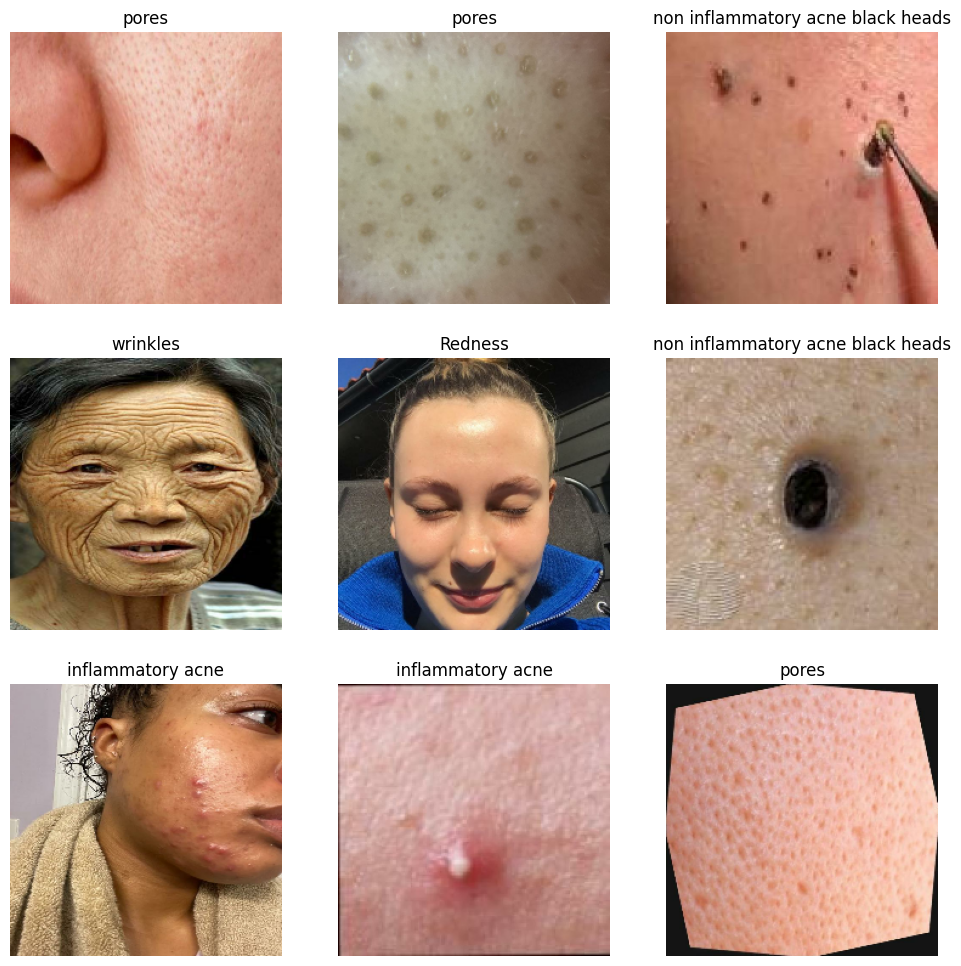

In [17]:
plt.figure(figsize=(12,12))

for images,labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[np.argmax(labels[i])])

        plt.axis("off")

plt.show()

In [18]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomContrast

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10)
])

In [20]:
base_model = applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

In [22]:
model.compile(

    optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,819 (15.49 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [24]:
early_stop = callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1

)

checkpoint = callbacks.ModelCheckpoint(

    "skin_issue_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [25]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/100


E0000 00:00:1782982870.481945      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2254 - loss: 1.9880
Epoch 1: val_accuracy improved from None to 0.42435, saving model to skin_issue_model.keras

Epoch 1: finished saving model to skin_issue_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.2761 - loss: 1.8921 - val_accuracy: 0.4243 - val_loss: 1.6612 - learning_rate: 1.0000e-04
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3829 - loss: 1.6789
Epoch 2: val_accuracy improved from 0.42435 to 0.52600, saving model to skin_issue_model.keras

Epoch 2: finished saving model to skin_issue_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.4178 - loss: 1.6163 - val_accuracy: 0.5260 - val_loss: 1.4457 - learning_rate: 1.0000e-04
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5001 - loss: 1.4521
Epoch 3: val_accuracy improved from 0.52600 to 0.57683, saving model to skin_issue_model.keras

Epoch 3: finished saving model to skin_issue_model.kera

## Plot Accuracy

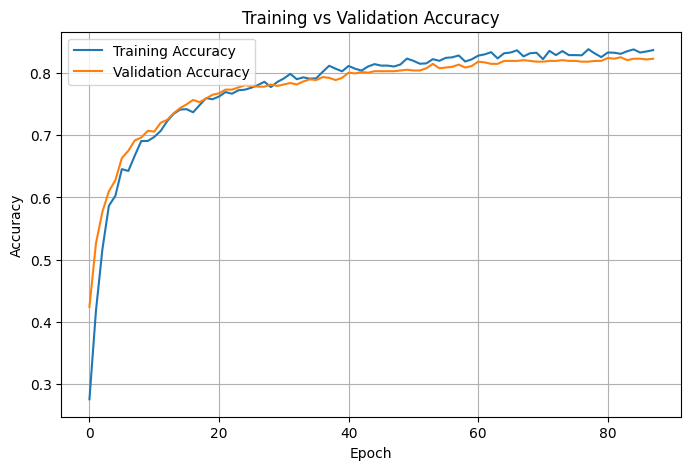

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Plot Loss

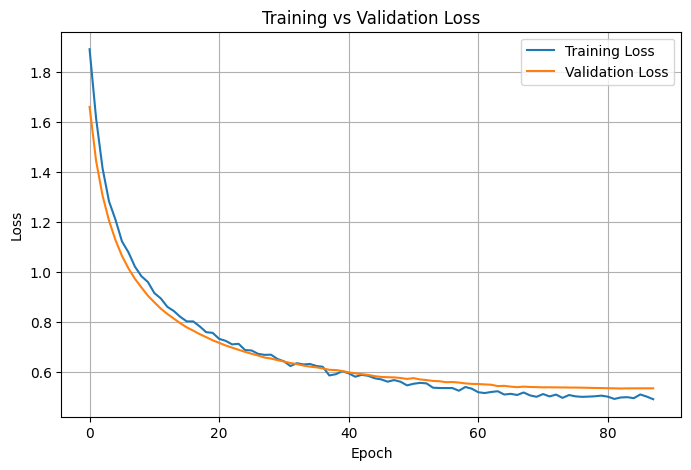

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Predict on Validation Dataset

In [28]:
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

## Classification Report

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                   precision    recall  f1-score   support

                          Redness       0.82      0.91      0.86       109
                       dark spots       0.70      0.70      0.70       139
                inflammatory acne       0.79      0.90      0.84       118
non inflammatory acne black heads       0.78      0.89      0.83        53
non inflammatory acne white heads       0.91      0.83      0.87        47
                     pigmentation       0.83      0.53      0.65       130
                            pores       0.88      0.98      0.93       132
                         wrinkles       0.92      0.95      0.93       118

                         accuracy                           0.83       846
                        macro avg       0.83      0.83      0.83       846
                     weighted avg       0.83      0.83      0.82       846



## CONFUSION MATRIX

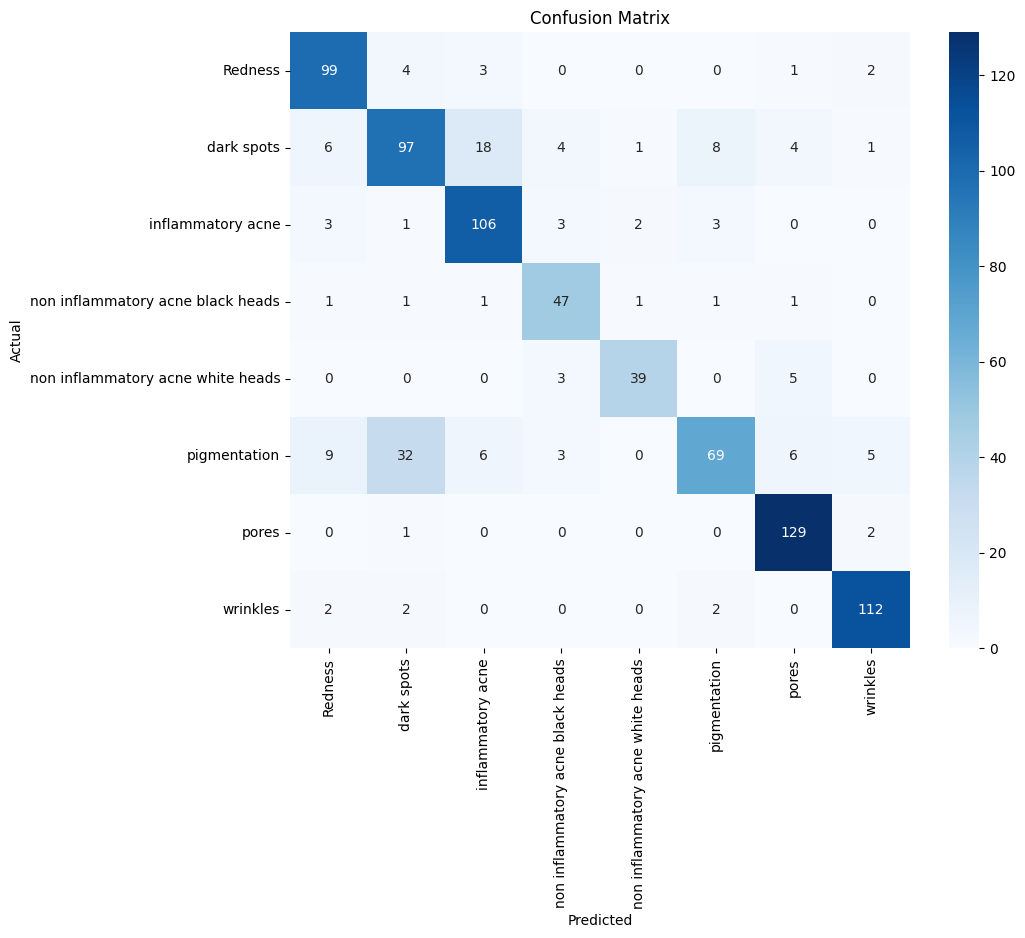

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Save Final Model

In [31]:
model.save("skin_issue_model.keras")

print("✅ Model saved successfully.")

✅ Model saved successfully.


## Save Class Names

In [32]:
import json

with open("skin_issue_classes.json", "w") as f:
    json.dump(class_names, f)

print("✅ Class names saved.")

✅ Class names saved.


## Test Prediction on One Image